In [120]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

In [121]:
df = pd.read_csv(r'd:\Startup\Project\ai-career-coach\data\processed\skill_frequencies.csv')

In [122]:
df.head()

,Skill,Count
0,analysis,92
1,python,87
2,sql,83
3,data visualization,68
4,research,57


In [123]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Skill   48 non-null     object
 1   Count   48 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 900.0+ bytes


In [124]:
df.isnull().sum()

Skill    0
Count    0
dtype: int64

In [125]:
df.sort_values(by='Count' , ascending= False ).head(10)

,Skill,Count
0,analysis,92
1,python,87
2,sql,83
3,data visualization,68
4,research,57
5,data analysis,56
6,communication,51
7,excel,50
8,power bi,45
9,tableau,38


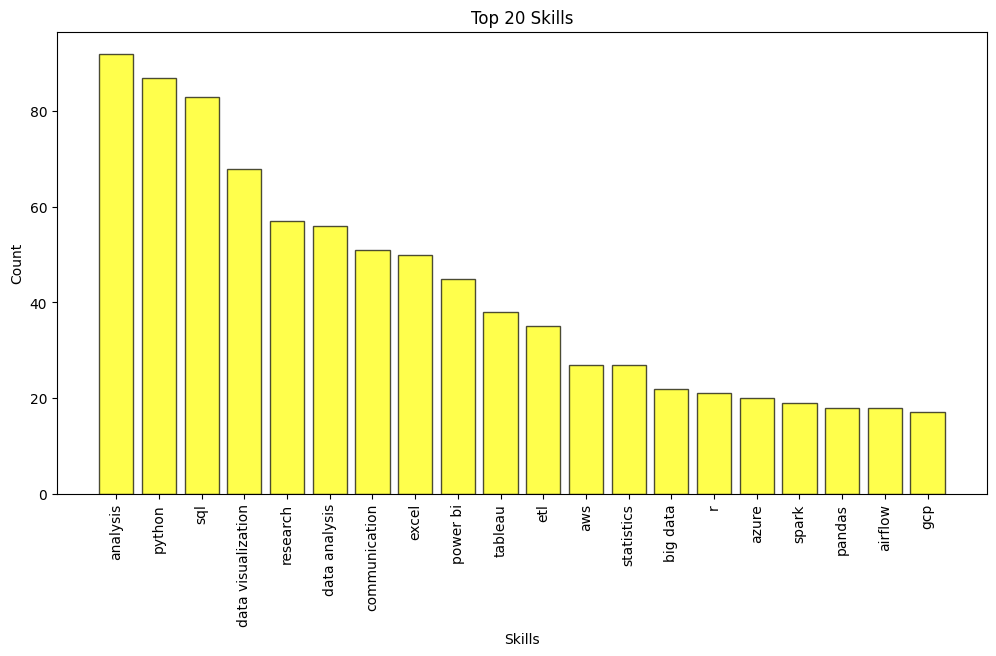

In [126]:
#Top 20 Skills Bar Chart 

top_skills = df.sort_values(by='Count' , 
                            ascending=False ).head(20)

plt.figure(figsize=(12,6))
plt.bar(x=top_skills['Skill'] ,
        height = top_skills['Count'] ,
                color = 'yellow' , 
                alpha = 0.7 , 
                edgecolor = 'black' , 
                linewidth = 1 )
plt.title('Top 20 Skills' , fontsize = 12)
plt.xlabel('Skills' , fontsize = 10)
plt.ylabel('Count' , fontsize = 10)
plt.xticks(rotation = 90)
plt.show()

these are some top deemanded skills by most of the job posts

In [127]:
exclude_skills = [
    "analysis",
    "research",
    "data analysis",
    "communication"
]

In [128]:
filtered_skill_df = df[~ df['Skill'] .isin(exclude_skills)].copy()


In [129]:
def category_skill(skill):
    if skill in ['python' , 'sql' , 'r' , 'java' , 'scala']:
        return 'Programming'
    elif skill in ['power bi' , 'tableau' , 'excel']:
        return 'BI'
    elif skill in ['aws' , 'gcp' , 'azure']:
        return 'Claud'
    elif skill in ['tensorflow' , 'sckit-learn' , 'pytorch' , 'machine learning']:
        return 'Machine Learning'
    elif skill in ['communication'   , 'problem solving' , 'presentation' ,'leadership' ]:
        return 'Soft Skills' 
    elif skill in ['postgresql' , 'oracle' , 'mysql' , 'mongodb' ]:
        return 'DataBase'
    elif skill in [ 'data preprocessing'  , 'pandas']:
        return 'Data Cleaning'
    elif skill in ['etl' , 'hadoop' ,'databricks' , 'dbt' ,'spark' , 'big data' ,'snowflake', 'airflow']:
        return 'Data Engineering'
    elif skill in ['nlp' , 'llm' , 'artificial intelligence']:
        return 'Artificial Intelligence'
    elif skill in ['ggplot2' , 'matplotlib' , 'data visualization' , 'seaborn' , 'dashboarding']:
        return 'Data Visualization'
    elif skill in [ "analysis", "research", "data analysis"]:
        return 'Generic Terms'
    else:
        return 'Other'

In [130]:
df['category'] = df['Skill'].apply(category_skill)


In [131]:
filtered_skill_df['category'] = filtered_skill_df['Skill'].apply(category_skill)

In [132]:
df['Skill'].unique()

array(['analysis', 'python', 'sql', 'data visualization', 'research',
       'data analysis', 'communication', 'excel', 'power bi', 'tableau',
       'etl', 'aws', 'statistics', 'big data', 'r', 'azure', 'spark',
       'pandas', 'airflow', 'gcp', 'snowflake', 'tensorflow', 'numpy',
       'dashboarding', 'leadership', 'pytorch', 'nlp', 'llm', 'java',
       'dbt', 'business analysis', 'presentation', 'hadoop', 'databricks',
       'matplotlib', 'mongodb', 'stakeholder management', 'kpi',
       'artificial intelligence', 'data preprocessing', 'seaborn',
       'postgresql', 'oracle', 'mysql', 'market research', 'scala',
       'computer vision', 'ggplot2'], dtype=object)

In [133]:
df[['Skill' , 'category']]

,Skill,category
0,analysis,Generic Terms
1,python,Programming
2,sql,Programming
3,data visualization,Data Visualization
4,research,Generic Terms
5,data analysis,Generic Terms
6,communication,Soft Skills
7,excel,BI
8,power bi,BI
9,tableau,BI


In [134]:
category_counts = df.groupby('category')['Count'].sum().sort_values(ascending=False)
filtered_category = category_counts.drop("Generic Terms")

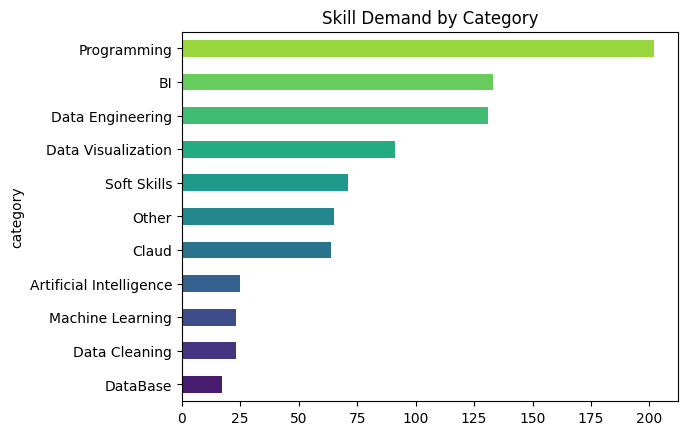

In [135]:
filtered_category.sort_values().plot(kind='barh',
                                   color = sns.color_palette('viridis' , len(category_counts)))
plt.title("Skill Demand by Category")
plt.show()

In [136]:
skill_count_dict = dict(
    zip(filtered_skill_df['Skill'] , filtered_skill_df['Count'])
)

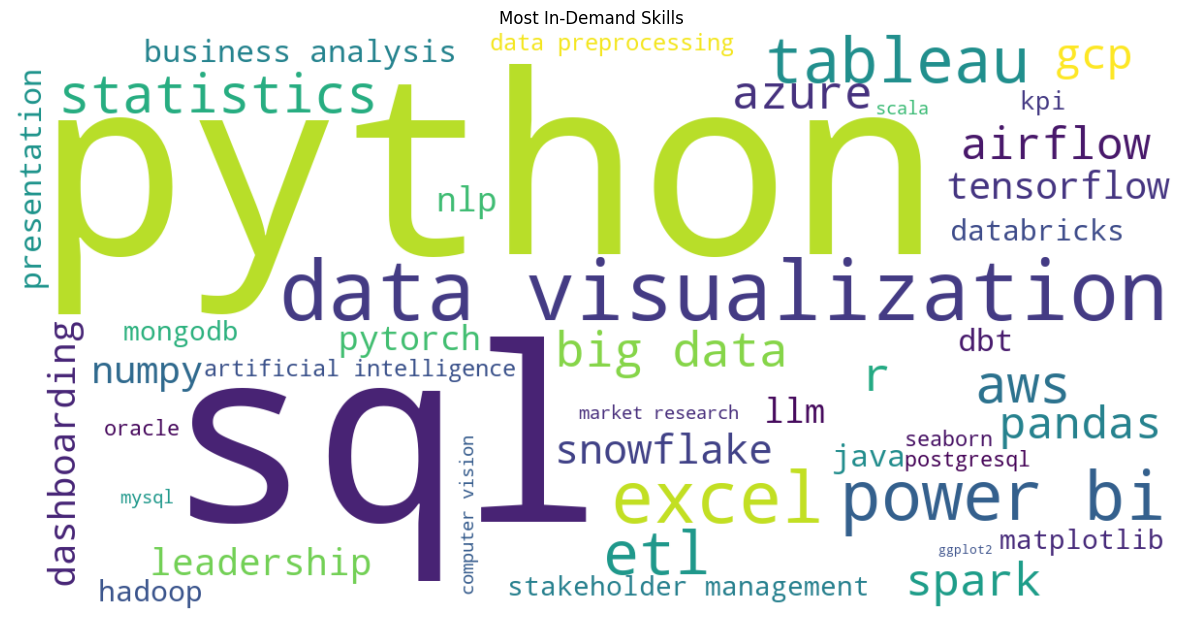

In [137]:
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate_from_frequencies(skill_count_dict)
plt.figure(figsize=(15,8))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Most In-Demand Skills")
plt.show()
# wordcloud.to_file(
#     "reports/dashboard_screenshots/skill_wordcloud.png"
# )

In [138]:
role_df = pd.read_csv(r"d:\Startup\Project\ai-career-coach\data\processed\role_skill_mapping.csv")

In [139]:

role_df_filtered =role_df[ ~role_df['Skill'].isin(exclude_skills)].copy()

In [140]:
role_df_filtered[role_df_filtered["Role"] == "Data Analyst"].head(10).sort_values(by = 'Count',ascending=False)

,Role,Skill,Count
7,Data Analyst,data visualization,28
5,Data Analyst,sql,25
11,Data Analyst,python,21
6,Data Analyst,power bi,16
10,Data Analyst,tableau,13
8,Data Analyst,excel,12
4,Data Analyst,r,10
9,Data Analyst,statistics,9
13,Data Analyst,pandas,7
0,Data Analyst,artificial intelligence,2


<Axes: xlabel='Skill', ylabel='Role'>

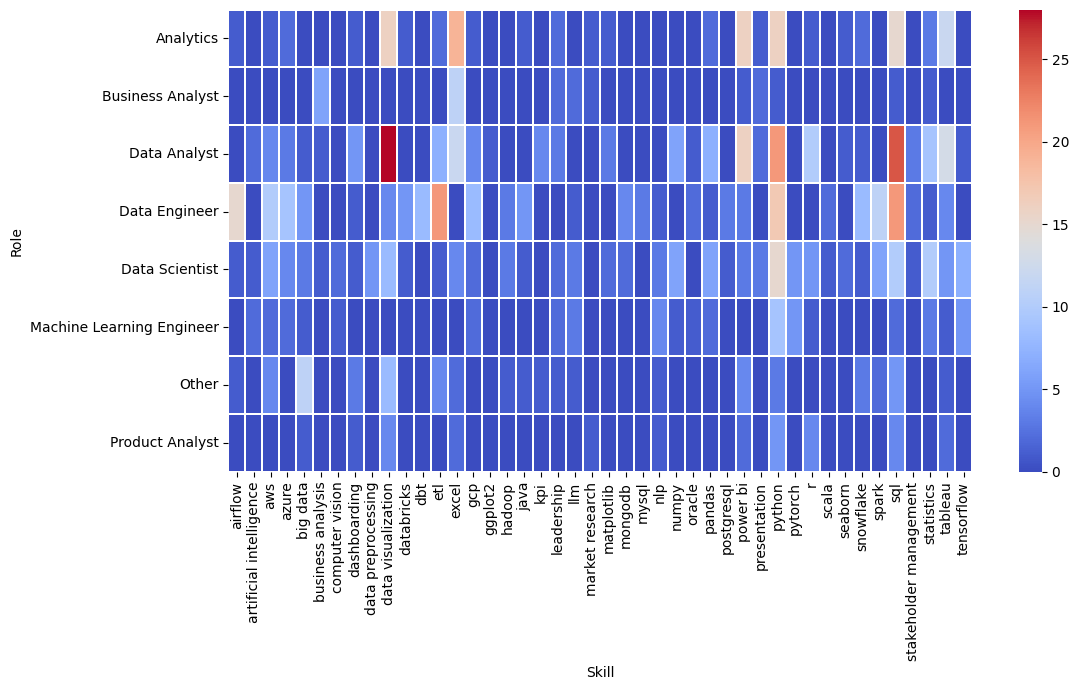

In [141]:
#creating pivot 
plt.figure(figsize=(12,6))
sns.heatmap(
role_df_filtered.pivot_table(
    index = 'Role' , 
    columns= 'Skill' ,
    values= 'Count', 
    fill_value= 0
) , cmap='coolwarm' , 
    linewidths=0.1,
    linecolor= 'white' )

In [142]:
def demand_level(count):
    if (count >= 40) :
        return 'High'
    elif (count < 40 ) and (count >= 15) :
        return 'Medium'
    else: 
        return 'Low'
    
filtered_skill_df['demand level']= filtered_skill_df['Count'].apply(demand_level)

In [143]:
filtered_skill_df['percentage_of_jobs'] = (
    filtered_skill_df['Count'] / len(role_df_filtered) * 100
)


In [144]:
filtered_skill_df["Rank"] = filtered_skill_df["Count"].rank(
    ascending=False,
    method="dense"
)

In [145]:
filtered_skill_df['Skill'].unique()

array(['python', 'sql', 'data visualization', 'excel', 'power bi',
       'tableau', 'etl', 'aws', 'statistics', 'big data', 'r', 'azure',
       'spark', 'pandas', 'airflow', 'gcp', 'snowflake', 'tensorflow',
       'numpy', 'dashboarding', 'leadership', 'pytorch', 'nlp', 'llm',
       'java', 'dbt', 'business analysis', 'presentation', 'hadoop',
       'databricks', 'matplotlib', 'mongodb', 'stakeholder management',
       'kpi', 'artificial intelligence', 'data preprocessing', 'seaborn',
       'postgresql', 'oracle', 'mysql', 'market research', 'scala',
       'computer vision', 'ggplot2'], dtype=object)

In [146]:
premium_skills = [
    'tensorflow', 'pytorch', 'nlp', 'llm', 'artificial intelligence',
    'computer vision', 'spark', 'hadoop', 'airflow', 'dbt',
    'databricks', 'snowflake', 'big data',
    'aws', 'azure', 'gcp',
    'scala', 'java'
]

        

In [147]:

filtered_skill_df['premium_skill'] = (filtered_skill_df['Skill']
                     .apply(lambda skill: 'Yes' if skill in premium_skills
                                           else 'No'))


In [148]:
skill_standardization_map = {
    # Programming Languages
    'python': 'Python',
    'r': 'R',
    'sql': 'SQL',
    'java': 'Java',
    'scala': 'Scala',

    # Data Analysis / Visualization
    'excel': 'Excel',
    'power bi': 'Power BI',
    'tableau': 'Tableau',
    'data visualization': 'Data Visualization',
    'dashboarding': 'Dashboarding',
    'matplotlib': 'Matplotlib',
    'seaborn': 'Seaborn',
    'ggplot2': 'GGPlot2',
    'kpi': 'KPI Analysis',

    # Databases
    'mysql': 'MySQL',
    'postgresql': 'PostgreSQL',
    'mongodb': 'MongoDB',
    'oracle': 'Oracle Database',
    'snowflake': 'Snowflake',

    # Data Engineering / Big Data
    'etl': 'ETL',
    'big data': 'Big Data',
    'spark': 'Apache Spark',
    'hadoop': 'Hadoop',
    'airflow': 'Apache Airflow',
    'dbt': 'dbt',
    'databricks': 'Databricks',

    # Cloud Platforms
    'aws': 'Amazon Web Services (AWS)',
    'azure': 'Microsoft Azure',
    'gcp': 'Google Cloud Platform (GCP)',

    # Machine Learning / AI
    'tensorflow': 'TensorFlow',
    'pytorch': 'PyTorch',
    'nlp': 'Natural Language Processing (NLP)',
    'llm': 'Large Language Models (LLMs)',
    'artificial intelligence': 'Artificial Intelligence (AI)',
    'computer vision': 'Computer Vision',

    # Statistics / Data Science
    'statistics': 'Statistics',
    'pandas': 'Pandas',
    'numpy': 'NumPy',
    'data preprocessing': 'Data Preprocessing',

    # Business / Soft Skills
    'business analysis': 'Business Analysis',
    'market research': 'Market Research',
    'stakeholder management': 'Stakeholder Management',
    'leadership': 'Leadership',
    'presentation': 'Presentation Skills'
}

In [149]:
filtered_skill_df['standardized_skills'] = filtered_skill_df['Skill'].map(skill_standardization_map)

In [150]:
filtered_skill_df

,Skill,Count,category,demand level,percentage_of_jobs,Rank,premium_skill,standardized_skills
1,python,87,Programming,High,49.431818,1.0,No,Python
2,sql,83,Programming,High,47.159091,2.0,No,SQL
3,data visualization,68,Data Visualization,High,38.636364,3.0,No,Data Visualization
7,excel,50,BI,High,28.409091,4.0,No,Excel
8,power bi,45,BI,High,25.568182,5.0,No,Power BI
9,tableau,38,BI,Medium,21.590909,6.0,No,Tableau
10,etl,35,Data Engineering,Medium,19.886364,7.0,No,ETL
11,aws,27,Claud,Medium,15.340909,8.0,Yes,Amazon Web Services (AWS)
12,statistics,27,Other,Medium,15.340909,8.0,No,Statistics
13,big data,22,Data Engineering,Medium,12.500000,9.0,Yes,Big Data
